# Estimation

This notebook estimates the job-search model

**Order of estimation**
1. L-BFGS-B: Standard 1-type, Standard 2-type, Standard 3-type, Reference-dependent 1-type.
2. LS-TRF: Standard 1-type, Standard 2-type, Standard 3-type, Reference-dependent 1-type.

For the **standard model**, `eta = 0` and `lambda = 0` are fixed. We estimate `delta`, `gamma`, the relevant search-cost parameters `k`, and the type shares `q`. `N` is fixed.

For the **reference-dependent model**, we use one type and estimate `delta`, `gamma`, `eta`, `k`, and `lambda`, while keeping `N` fixed.

This notebook produces:
- initial-fit and post-estimation hazard plots;
- estimation tables in both DataFrame and LaTeX form;
- goodness of fit (SSE);
- elapsed estimation time;
- a type-survival / survivor-composition for heterogeneous-type models.

## 1. Setup

Set `MODEL_DIR` to the folder containing `Model_components.py` if needed. The code below uses the same local path as the existing notebook by default.

In [1]:
# magics: ensures that any changes to the modules loaded below will be re-loaded automatically
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

import os
import sys
import time

import numpy as np
from time import process_time
import matplotlib.pyplot as plt
from scipy import interpolate 
import optimagic as om
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import pandas as pd
import scipy.optimize as opt
from scipy.optimize import fsolve
from scipy.stats import beta


MODEL_DIR = os.environ.get(
    "JOB_SEARCH_MODEL_DIR",
    "C:\\Users\\jap\\OneDrive - ROCKWOOL FONDEN\\Python Workspace\\termpaper_dynprog\\Job Search\\"
)

MODEL_DIR = os.environ.get(
    "JOB_SEARCH_MODEL_DIR",
    '/Users/albertolsen/Documents/Stud Polit/9. semester/Dynamic Programming/Exam/termpaper_dynprog/Job Search'
)



if MODEL_DIR not in sys.path:
    sys.path.append(MODEL_DIR)

import Model_components as model

FIGURE_DIR = os.path.join(os.getcwd(), "estimation_figures")
TABLE_DIR = os.path.join(os.getcwd(), "estimation_tables")
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

pd.set_option("display.float_format", lambda x: f"{x:,.5f}")

## 2. Parameters and institutions

The computational asset grid and the initial asset distribution are separate objects. `abar` controls the state space; `weights` controls how initial asset states are represented in the simulated population.

For faster exploratory estimation, reduce `n_a` and/or `n_c`. Re-solve the final estimates on a finer grid as a robustness check.

In [2]:
# Baseline structural values / starting values
delta = 0.89
gamma = 0.81
eta_rd = 1.0
beta = 0.8

k = 359.0
k1 = 300.0
k2 = 150.0
k3 = 90.0

q1 = 0.33
q2 = 0.33

lmbda_rd = 4.9
N = 6

# Asset state space
abar = [0, 17955]

# Grid sizes
n_a = 50
n_c = 100

# Timing
T1 = 6
T2 = 18
T3 = 24
T = 44

# Pre-reform benefits
b1_pre = 222
b2_pre = 222
b3 = 114

# Post-reform benefits
b1_post = 342
b2_post = 171

welfare = 90
w = 675
R = 0.01

# 0 = heterogeneous assets; 1 = hand-to-mouth
htm = 0

institutions_pre = np.array([
    n_a, n_c, T1, T2, T3, T,
    b1_pre, b2_pre, b3, welfare, w, R
])

institutions_post = np.array([
    n_a, n_c, T1, T2, T3, T,
    b1_post, b2_post, b3, welfare, w, R
])

weights = model.make_weights(htm, abar, n_a)

target, cov = model.matchingMoments()
W = np.linalg.inv(cov)

# matchingMoments() drops the first empirical 15-day moment.
# Hence 35 retained observations correspond to days 30,...,540.
timevec = np.arange(15, 526, 15)

def split_half(arr):
    arr = np.asarray(arr)
    mid = len(arr) // 2
    return arr[:mid], arr[mid:]

emp_pre, emp_post = split_half(target)

print("Number of moments:", len(target))
print("Asset weights sum to:", weights.sum())

Number of moments: 70
Asset weights sum to: 1.0000000000000002


## 3. Model specifications

The parameter vectors must match the ordering expected by `SolveMultiTypeModel`.

- Standard 1 type: `[delta, gamma, 0, k1, 0, N]`
- Standard 2 type: `[delta, gamma, 0, k1, 0, N, k2, q1]`
- Standard 3 type: `[delta, gamma, 0, k1, 0, N, k2, k3, q1, q2]`
- RD 1 type: `[delta, gamma, eta, k1, lambda, N]`

For the 3-type model, the current model defines the third share as `1 - q1 - q2`. The box bounds below keep `q1 + q2 < 1` throughout optimization.

In [3]:
def make_specs():
    specs = {}

    specs["Standard 1 type"] = {
        "full": pd.DataFrame(
            {"value": [delta, gamma, 0.0, k, 0.0, N]},
            index=["delta", "gamma", "eta", "k1", "lmbda", "N"]
        ),
        "free": pd.DataFrame(
            {
                "value": [delta, gamma, k],
                "lower_bound": [0.01, 1e-2, 1e-5],
                "upper_bound": [0.95, 2.0, 2000.0],
            },
            index=["delta", "gamma", "k1"]
        ),
    }

    specs["Standard 2 type"] = {
        "full": pd.DataFrame(
            {"value": [delta, gamma, 0.0, k1, 0.0, N, k2, q1]},
            index=["delta", "gamma", "eta", "k1", "lmbda", "N", "k2", "q1"]
        ),
        "free": pd.DataFrame(
            {
                "value": [delta, gamma, k1, k2, q1],
                "lower_bound": [0.01, 1e-2, 1e-5, 1e-5, 0.01],
                "upper_bound": [0.95, 2.0, 2000.0, 2000.0, 0.99],
            },
            index=["delta", "gamma", "k1", "k2", "q1"]
        ),
    }

    specs["Standard 3 type"] = {
        "full": pd.DataFrame(
            {"value": [delta, gamma, 0.0, k1, 0.0, N, k2, k3, q1, q2]},
            index=["delta", "gamma", "eta", "k1", "lmbda", "N", "k2", "k3", "q1", "q2"]
        ),
        "free": pd.DataFrame(
            {
                "value": [delta, gamma, k1, k2, k3, q1, q2],
                "lower_bound": [0.01, 1e-2, 1e-5, 1e-5, 1e-5, 0.01, 0.01],
                # Conservative share bounds guarantee q3 = 1-q1-q2 > 0.
                # Relax using an Optimagic linear constraint if desired.
                "upper_bound": [0.95, 2.0, 2000.0, 2000.0, 2000.0, 0.49, 0.49],
            },
            index=["delta", "gamma", "k1", "k2", "k3", "q1", "q2"]
        ),
    }

    specs["Reference dependent 1 type"] = {
        "full": pd.DataFrame(
            {"value": [delta, gamma, eta_rd, k, lmbda_rd, N]},
            index=["delta", "gamma", "eta", "k1", "lmbda", "N"]
        ),
        "free": pd.DataFrame(
            {
                "value": [delta, gamma, eta_rd, k, lmbda_rd],
                "lower_bound": [0.01, 1e-2, 0.01, 1e-5, 0.01],
                "upper_bound": [0.95, 2.0, 15.0, 2000.0, 15.0],
            },
            index=["delta", "gamma", "eta", "k1", "lmbda"]
        ),
    }

    return specs

specs = make_specs()

for name, spec in specs.items():
    print(name)
    display(spec["free"])

Standard 1 type


,value,lower_bound,upper_bound
delta,0.89000,0.01000,0.95000
gamma,0.81000,0.01000,2.00000
k1,359.00000,0.00001,"2,000.00000"


Standard 2 type


,value,lower_bound,upper_bound
delta,0.89000,0.01000,0.95000
gamma,0.81000,0.01000,2.00000
k1,300.00000,0.00001,"2,000.00000"
k2,150.00000,0.00001,"2,000.00000"
q1,0.33000,0.01000,0.99000


Standard 3 type


,value,lower_bound,upper_bound
delta,0.89000,0.01000,0.95000
gamma,0.81000,0.01000,2.00000
k1,300.00000,0.00001,"2,000.00000"
k2,150.00000,0.00001,"2,000.00000"
k3,90.00000,0.00001,"2,000.00000"
q1,0.33000,0.01000,0.49000
q2,0.33000,0.01000,0.49000


Reference dependent 1 type


,value,lower_bound,upper_bound
delta,0.89000,0.01000,0.95000
gamma,0.81000,0.01000,2.00000
eta,1.00000,0.01000,15.00000
k1,359.00000,0.00001,"2,000.00000"
lmbda,4.90000,0.01000,15.00000


## 4. Helper functions
These functions makes the estimation much more neat and does the following
- Create a vector of the values of the estimated parameters + those that were fixed
- Create a vector of initial values to input in the estimation
- Simulate moments (only need to input the parameters dependent on model type)
- Plot the simulated/estimated moments against the empirical moments
- Run the estimation (only need to input model name and estimation algorithm)
- Output estimation results, algorithm used, model used, SSE (goodness of fit), time it took for the estimation for a table

*** Note ***
`L-BFGS-B` uses the SSE criterion. `LS-TRF` uses the residual-vector criterion (cholesky decomposition) because it is a least-squares algorithm.



In [4]:
def full_vector_from_result(spec, result):
    full = spec["full"].copy()
    full.update(result.params)
    return full["value"].to_numpy()


def initial_vector(spec):
    return spec["full"]["value"].to_numpy().copy()


def simulate_fit(params_vec):
    moments = model.simulate_moments(
        params_vec,
        institutions_pre,
        institutions_post,
        abar,
        weights,
        htm,
    )
    return split_half(moments)


def plot_fit(params_vec, title, filename=None):
    pred_pre, pred_post = simulate_fit(params_vec)

    

    plt.plot(timevec, emp_pre, marker=".", label="Empirical pre-reform",  color='tab:blue')
    plt.plot(timevec, emp_post, marker=".", label="Empirical post-reform",  color='tab:red')
    plt.plot(timevec, pred_pre, linestyle="--", label="Model pre-reform", color='tab:blue')
    plt.plot(timevec, pred_post, linestyle="--", label="Model post-reform", color='tab:red')

    plt.vlines(x=[(T1)*15, (T2)*15, (T3)*15], ymin=0, ymax=0.1, colors='black', linestyles='dashed')

    plt.xlabel("Number of days since UI claim")
    plt.ylabel("Hazard rate")
    plt.title(title)
    plt.xlim(0, 560)
    plt.ylim(0, 0.1)
    plt.xticks(np.arange(0, 541, 90))
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    

    if filename is not None:
        plt.savefig(os.path.join(FIGURE_DIR, filename), bbox_inches="tight")

    plt.show()
    


def run_estimation(model_name, algorithm):
    spec = specs[model_name]

    smm_object = model.smm(
        spec["full"].copy(),
        target,
        W,
        institutions_pre,
        institutions_post,
        abar,
        weights,
        htm,
    )

    if algorithm == "scipy_lbfgsb":
        criterion = smm_object.sse
    elif algorithm == "scipy_ls_trf":
        criterion = smm_object.criterion
    else:
        raise ValueError("Unsupported algorithm.")

    start = time.perf_counter()

    result = om.minimize(
        criterion=criterion,
        params=spec["free"].copy(),
        algorithm=algorithm,
    )

    elapsed = time.perf_counter() - start

    params_hat = full_vector_from_result(spec, result)

    # Compute the same quadratic SSE for all algorithms for direct comparison.
    sse_hat = model.sse(
        params_hat,
        target,
        W,
        institutions_pre,
        institutions_post,
        abar,
        weights,
        htm,
    )

    return {
        "model": model_name,
        "algorithm": algorithm,
        "result": result,
        "params_hat": params_hat,
        "sse": float(sse_hat),
        "seconds": elapsed,
        "full_index": list(spec["full"].index),
    }


def result_row(out):
    values = dict(zip(out["full_index"], out["params_hat"]))
    return {
        "Algorithm": out["algorithm"],
        "Model": out["model"],
        "delta": values.get("delta", np.nan),
        "gamma": values.get("gamma", np.nan),
        "eta": values.get("eta", np.nan),
        "lambda": values.get("lmbda", np.nan),
        "k1": values.get("k1", np.nan),
        "k2": values.get("k2", np.nan),
        "k3": values.get("k3", np.nan),
        "q1": values.get("q1", np.nan),
        "q2": values.get("q2", np.nan),
        "q3": (
            1 - values.get("q1", 0) - values.get("q2", 0)
            if "q2" in values else
            (1 - values.get("q1", 0) if "q1" in values else np.nan)
        ),
        "SSE": out["sse"],
        "Minutes": out["seconds"] / 60,
    }


results = {}

# 5. L-BFGS-B

Each subsection first plots the fit at the starting values, then estimates the model, and finally plots the fitted hazards at the estimated parameters.

## 5.1 Standard 1-type

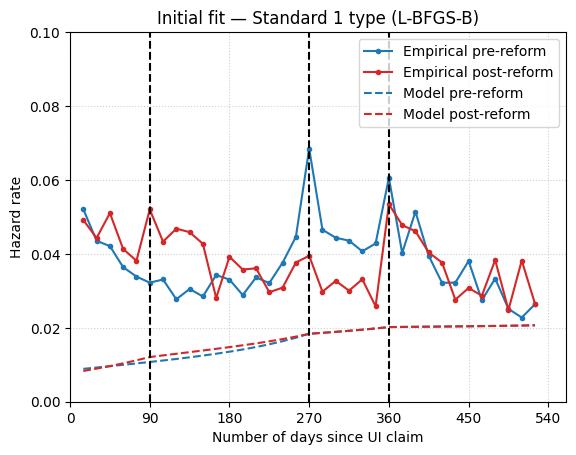

In [5]:
plot_fit(
    initial_vector(specs['Standard 1 type']),
    'Initial fit — Standard 1 type (L-BFGS-B)',
    'lbfgsb_st1_before.pdf',
)

In [6]:
results[("L-BFGS-B", 'Standard 1 type')] = run_estimation(
    'Standard 1 type',
    "scipy_lbfgsb"
)

out = results[("L-BFGS-B", 'Standard 1 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

c:\Users\jap\AppData\Local\miniconda3\Lib\site-packages\optimagic\deprecations.py:53: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)


Estimated parameters: [  0.9138094    0.97702111   0.         358.1948081    0.
   6.        ]
SSE: 559.741422
Elapsed: 8.59 minutes


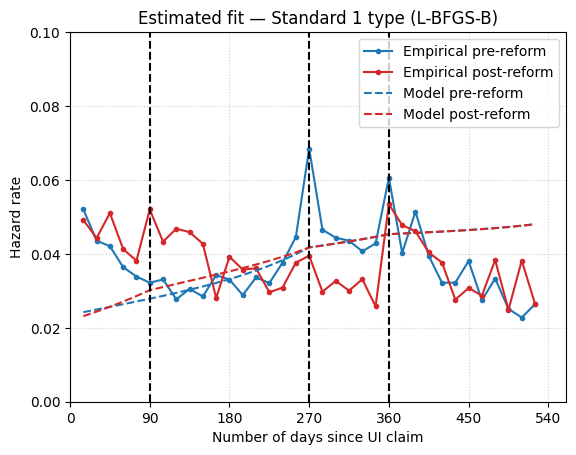

In [7]:
plot_fit(
    results[("L-BFGS-B", 'Standard 1 type')]["params_hat"],
    'Estimated fit — Standard 1 type (L-BFGS-B)',
    'lbfgsb_st1_after.pdf',
)

## 5.2 Standard 2-type

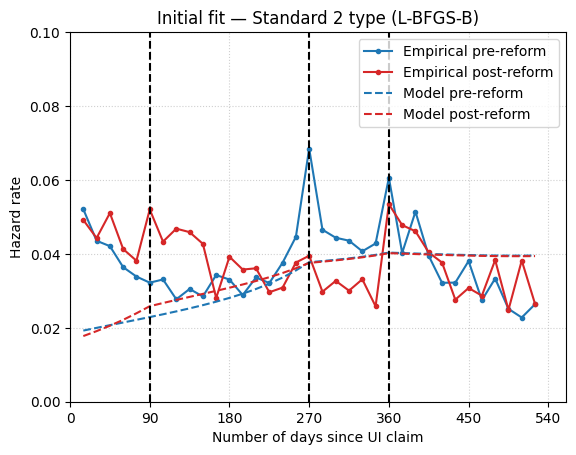

In [8]:
plot_fit(
    initial_vector(specs['Standard 2 type']),
    'Initial fit — Standard 2 type (L-BFGS-B)',
    'lbfgsb_st2_before.pdf',
)

In [9]:
results[("L-BFGS-B", 'Standard 2 type')] = run_estimation(
    'Standard 2 type',
    "scipy_lbfgsb"
)

out = results[("L-BFGS-B", 'Standard 2 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

c:\Users\jap\AppData\Local\miniconda3\Lib\site-packages\optimagic\deprecations.py:53: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)


Estimated parameters: [  0.94221307   0.72518965   0.         300.03635862   0.
   6.         150.52343132   0.60478785]
SSE: 517.729820
Elapsed: 32.08 minutes


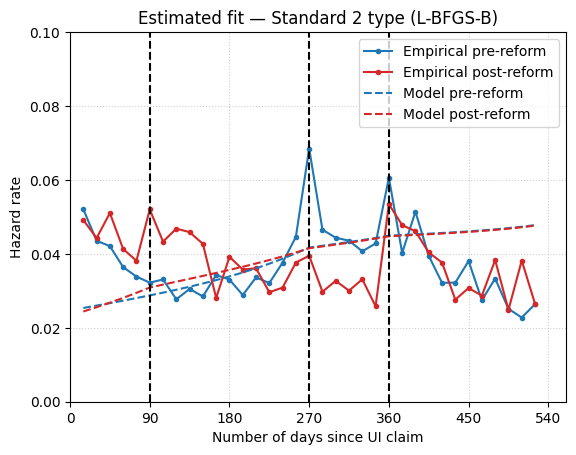

In [10]:
plot_fit(
    results[("L-BFGS-B", 'Standard 2 type')]["params_hat"],
    'Estimated fit — Standard 2 type (L-BFGS-B)',
    'lbfgsb_st2_after.pdf',
)

## 5.3 Standard 3-type

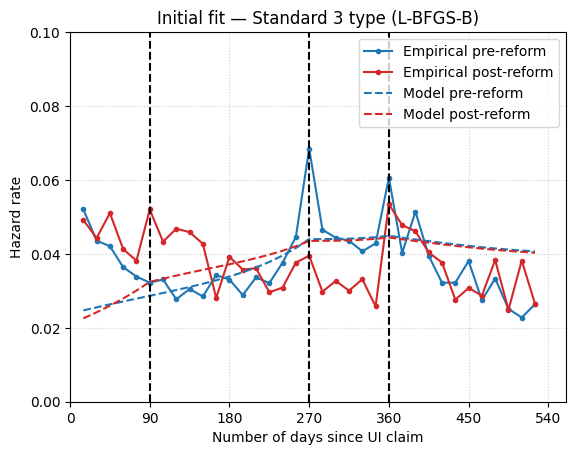

In [11]:
plot_fit(
    initial_vector(specs['Standard 3 type']),
    'Initial fit — Standard 3 type (L-BFGS-B)',
    'lbfgsb_st3_before.pdf',
)

In [12]:
results[("L-BFGS-B", 'Standard 3 type')] = run_estimation(
    'Standard 3 type',
    "scipy_lbfgsb"
)

out = results[("L-BFGS-B", 'Standard 3 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

c:\Users\jap\AppData\Local\miniconda3\Lib\site-packages\optimagic\deprecations.py:53: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)


Estimated parameters: [9.03269619e-01 7.95118463e-01 0.00000000e+00 3.97626953e+02
 0.00000000e+00 6.00000000e+00 1.38627734e+02 1.82585105e+01
 3.51556658e-01 4.24856733e-01]
SSE: 95.521585
Elapsed: 68.32 minutes


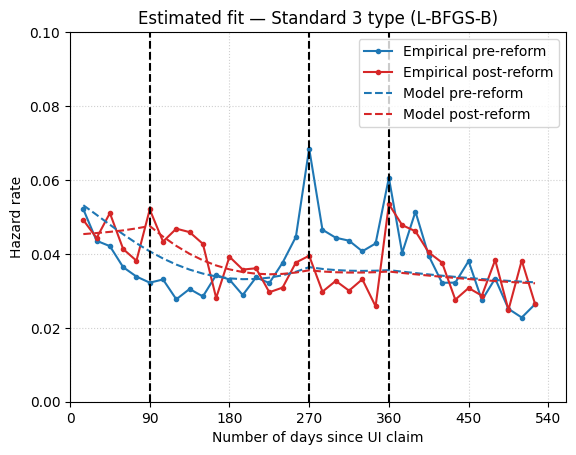

In [13]:
plot_fit(
    results[("L-BFGS-B", 'Standard 3 type')]["params_hat"],
    'Estimated fit — Standard 3 type (L-BFGS-B)',
    'lbfgsb_st3_after.pdf',
)

## 5.4 Reference dependent 1 type

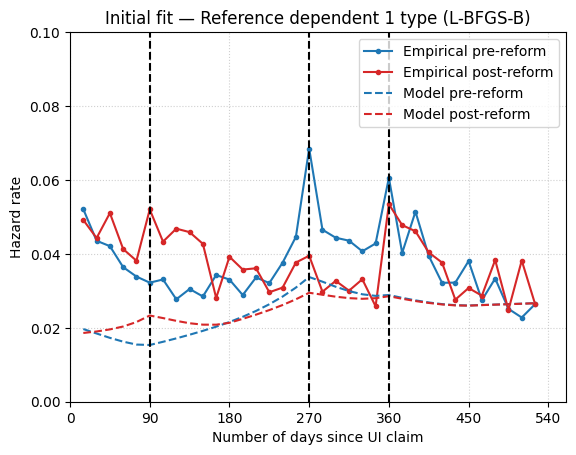

In [14]:
plot_fit(
    initial_vector(specs['Reference dependent 1 type']),
    'Initial fit — Reference dependent 1 type (L-BFGS-B)',
    'lbfgsb_rd1_before.pdf',
)

In [15]:
results[("L-BFGS-B", 'Reference dependent 1 type')] = run_estimation(
    'Reference dependent 1 type',
    "scipy_lbfgsb"
)

out = results[("L-BFGS-B", 'Reference dependent 1 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

c:\Users\jap\AppData\Local\miniconda3\Lib\site-packages\optimagic\deprecations.py:53: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)


Estimated parameters: [  0.95         0.66311239   1.07306839 358.51466885  13.8702157
   6.        ]
SSE: 133.367606
Elapsed: 19.53 minutes


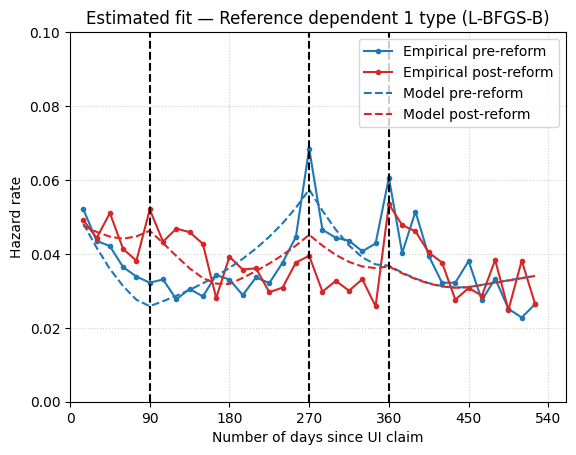

In [16]:
plot_fit(
    results[("L-BFGS-B", 'Reference dependent 1 type')]["params_hat"],
    'Estimated fit — Reference dependent 1 type (L-BFGS-B)',
    'lbfgsb_rd1_after.pdf',
)

## 5.5 Estimation Table 1 (L-BFGS-B)

The LaTeX table is printed in the notebook and also saved to `estimation_tables/lbfgsb_results.tex`.

In [17]:
lbfgsb_table = pd.DataFrame([
    result_row(results[("L-BFGS-B", name)])
    for name in specs.keys()
])

display(lbfgsb_table)

lbfgsb_latex = lbfgsb_table.to_latex(
    index=False,
    float_format=lambda x: f"{x:.4f}",
    na_rep="--",
    caption="SMM estimates using L-BFGS-B.",
    label="tab:lbfgsb_estimates",
)

print(lbfgsb_latex)

with open(os.path.join(TABLE_DIR, "lbfgsb_results.tex"), "w", encoding="utf-8") as f:
    f.write(lbfgsb_latex)

,Algorithm,Model,delta,gamma,eta,lambda,k1,k2,k3,q1,q2,q3,SSE,Minutes
0,scipy_lbfgsb,Standard 1 type,0.91381,0.97702,0.00000,0.00000,358.19481,NaN,NaN,NaN,NaN,NaN,559.74142,8.59367
1,scipy_lbfgsb,Standard 2 type,0.94221,0.72519,0.00000,0.00000,300.03636,150.52343,NaN,0.60479,NaN,0.39521,517.72982,32.07506
2,scipy_lbfgsb,Standard 3 type,0.90327,0.79512,0.00000,0.00000,397.62695,138.62773,18.25851,0.35156,0.42486,0.22359,95.52158,68.31669
3,scipy_lbfgsb,Reference dependent 1 type,0.95000,0.66311,1.07307,13.87022,358.51467,NaN,NaN,NaN,NaN,NaN,133.36761,19.52800


\begin{table}
\caption{SMM estimates using L-BFGS-B.}
\label{tab:lbfgsb_estimates}
\begin{tabular}{llrrrrrrrrrrrr}
\toprule
Algorithm & Model & delta & gamma & eta & lambda & k1 & k2 & k3 & q1 & q2 & q3 & SSE & Minutes \\
\midrule
scipy_lbfgsb & Standard 1 type & 0.9138 & 0.9770 & 0.0000 & 0.0000 & 358.1948 & -- & -- & -- & -- & -- & 559.7414 & 8.5937 \\
scipy_lbfgsb & Standard 2 type & 0.9422 & 0.7252 & 0.0000 & 0.0000 & 300.0364 & 150.5234 & -- & 0.6048 & -- & 0.3952 & 517.7298 & 32.0751 \\
scipy_lbfgsb & Standard 3 type & 0.9033 & 0.7951 & 0.0000 & 0.0000 & 397.6270 & 138.6277 & 18.2585 & 0.3516 & 0.4249 & 0.2236 & 95.5216 & 68.3167 \\
scipy_lbfgsb & Reference dependent 1 type & 0.9500 & 0.6631 & 1.0731 & 13.8702 & 358.5147 & -- & -- & -- & -- & -- & 133.3676 & 19.5280 \\
\bottomrule
\end{tabular}
\end{table}



# 6. LS-TRF

LS-TRF uses `smm_object.criterion`, which returns root contributions for the least-squares solver. The reported SSE is recomputed using the same quadratic criterion as for L-BFGS-B.

## 6.1 Standard 1-type

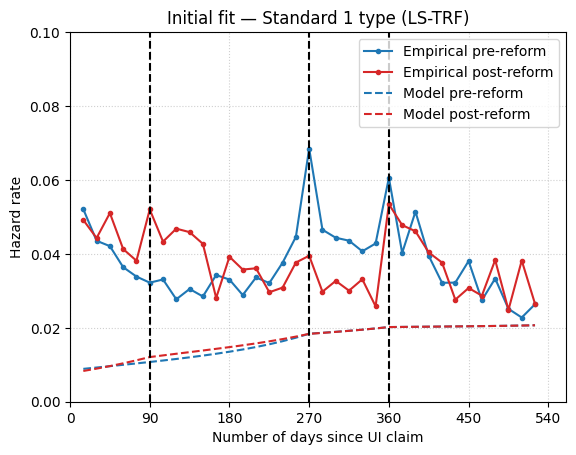

In [18]:
plot_fit(
    initial_vector(specs['Standard 1 type']),
    'Initial fit — Standard 1 type (LS-TRF)',
    'lstrf_st1_before.pdf',
)

In [19]:
results[("LS-TRF", 'Standard 1 type')] = run_estimation(
    'Standard 1 type',
    "scipy_ls_trf"
)

out = results[("LS-TRF", 'Standard 1 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

c:\Users\jap\AppData\Local\miniconda3\Lib\site-packages\optimagic\deprecations.py:53: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)
c:\Users\jap\AppData\Local\miniconda3\Lib\site-packages\optimagic\deprecations.py:333: FutureWarning: Returning a dictionary with the special keys 'value', 'contributions', or 'root_contributions' is deprecated and will be removed in optimagic version 0.6.0 and later. Please use the optimagic.mark.scalar, optimagic.mark.least_squares, or optimagic.mark.likelihood decorators to indicate the type of problem you are solving. Use optimagic.FunctionValue objects to return additional information for the logging. Please see the documentation for more details: https://optimagic.readthedocs.io/en/latest/how_to/how_to_criterion_function.html
  warnings.w

Estimated parameters: [  0.91675751   0.92671543   0.         315.82580651   0.
   6.        ]
SSE: 578.557492
Elapsed: 1.27 minutes


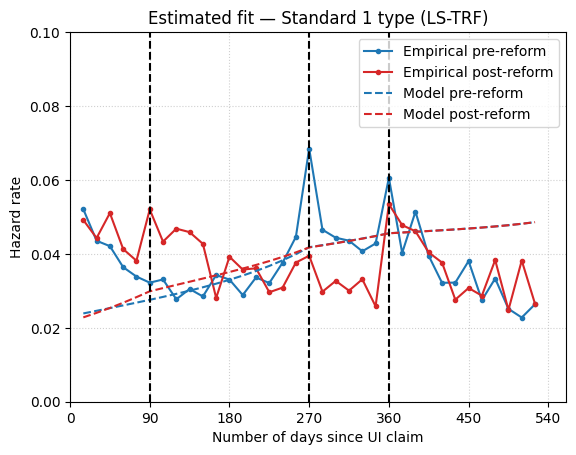

In [20]:
plot_fit(
    results[("LS-TRF", 'Standard 1 type')]["params_hat"],
    'Estimated fit — Standard 1 type (LS-TRF)',
    'lstrf_st1_after.pdf',
)

## 6.2 Standard 2-type

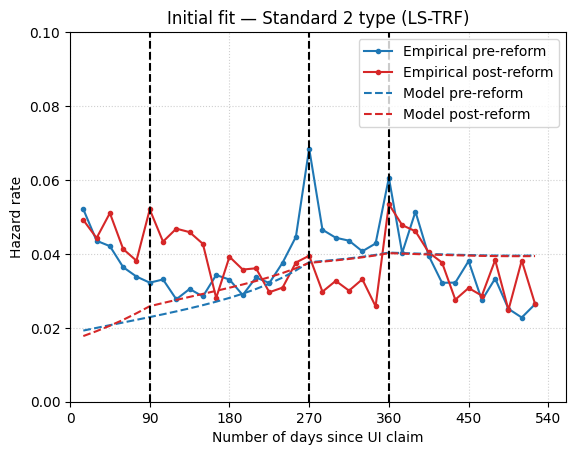

In [21]:
plot_fit(
    initial_vector(specs['Standard 2 type']),
    'Initial fit — Standard 2 type (LS-TRF)',
    'lstrf_st2_before.pdf',
)

In [22]:
results[("LS-TRF", 'Standard 2 type')] = run_estimation(
    'Standard 2 type',
    "scipy_ls_trf"
)

out = results[("LS-TRF", 'Standard 2 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

c:\Users\jap\AppData\Local\miniconda3\Lib\site-packages\optimagic\deprecations.py:53: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)
c:\Users\jap\AppData\Local\miniconda3\Lib\site-packages\optimagic\deprecations.py:333: FutureWarning: Returning a dictionary with the special keys 'value', 'contributions', or 'root_contributions' is deprecated and will be removed in optimagic version 0.6.0 and later. Please use the optimagic.mark.scalar, optimagic.mark.least_squares, or optimagic.mark.likelihood decorators to indicate the type of problem you are solving. Use optimagic.FunctionValue objects to return additional information for the logging. Please see the documentation for more details: https://optimagic.readthedocs.io/en/latest/how_to/how_to_criterion_function.html
  warnings.w

Estimated parameters: [8.27847552e-01 1.36317620e+00 0.00000000e+00 8.99937867e+02
 0.00000000e+00 6.00000000e+00 3.59179039e+01 7.51095163e-01]
SSE: 96.626462
Elapsed: 7.82 minutes


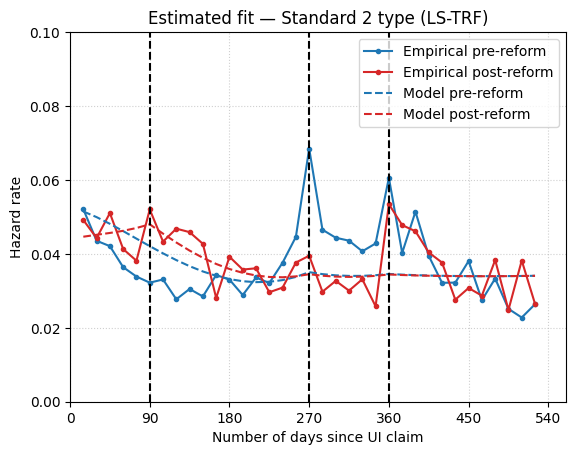

In [23]:
plot_fit(
    results[("LS-TRF", 'Standard 2 type')]["params_hat"],
    'Estimated fit — Standard 2 type (LS-TRF)',
    'lstrf_st2_after.pdf',
)

## 6.3 Standard 3-type

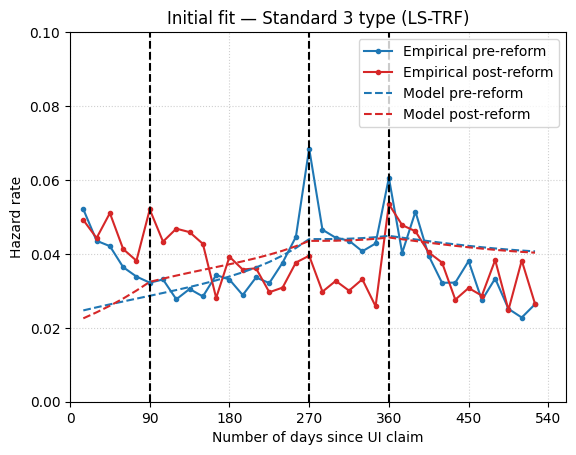

In [24]:
plot_fit(
    initial_vector(specs['Standard 3 type']),
    'Initial fit — Standard 3 type (LS-TRF)',
    'lstrf_st3_before.pdf',
)

In [25]:
results[("LS-TRF", 'Standard 3 type')] = run_estimation(
    'Standard 3 type',
    "scipy_ls_trf"
)

out = results[("LS-TRF", 'Standard 3 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

c:\Users\jap\AppData\Local\miniconda3\Lib\site-packages\optimagic\deprecations.py:53: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)
c:\Users\jap\AppData\Local\miniconda3\Lib\site-packages\optimagic\deprecations.py:333: FutureWarning: Returning a dictionary with the special keys 'value', 'contributions', or 'root_contributions' is deprecated and will be removed in optimagic version 0.6.0 and later. Please use the optimagic.mark.scalar, optimagic.mark.least_squares, or optimagic.mark.likelihood decorators to indicate the type of problem you are solving. Use optimagic.FunctionValue objects to return additional information for the logging. Please see the documentation for more details: https://optimagic.readthedocs.io/en/latest/how_to/how_to_criterion_function.html
  warnings.w

Estimated parameters: [7.76798039e-01 1.28588022e+00 0.00000000e+00 7.30853708e+02
 0.00000000e+00 6.00000000e+00 2.00339193e+02 1.66959870e+01
 4.89892204e-01 3.19660328e-01]
SSE: 94.688959
Elapsed: 5.88 minutes


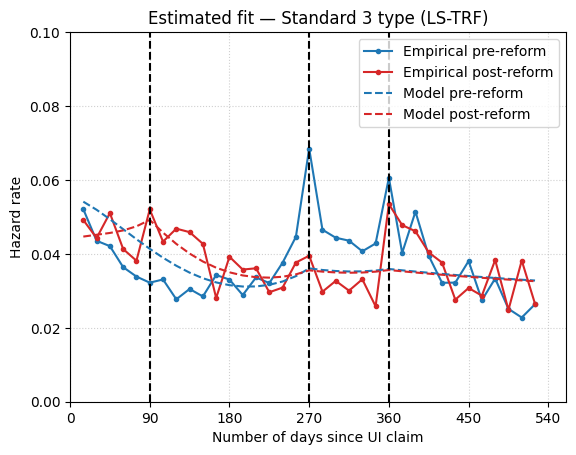

In [26]:
plot_fit(
    results[("LS-TRF", 'Standard 3 type')]["params_hat"],
    'Estimated fit — Standard 3 type (LS-TRF)',
    'lstrf_st3_after.pdf',
)

## 6.4 Reference dependent 1 type

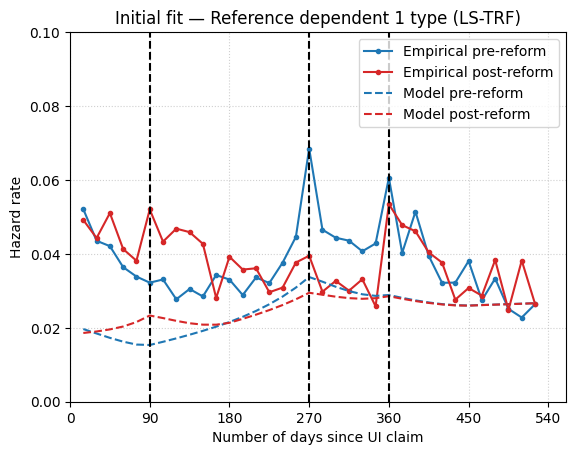

In [27]:
plot_fit(
    initial_vector(specs['Reference dependent 1 type']),
    'Initial fit — Reference dependent 1 type (LS-TRF)',
    'lstrf_rd1_before.pdf',
)

In [28]:
results[("LS-TRF", 'Reference dependent 1 type')] = run_estimation(
    'Reference dependent 1 type',
    "scipy_ls_trf"
)

out = results[("LS-TRF", 'Reference dependent 1 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

c:\Users\jap\AppData\Local\miniconda3\Lib\site-packages\optimagic\deprecations.py:53: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)
c:\Users\jap\AppData\Local\miniconda3\Lib\site-packages\optimagic\deprecations.py:333: FutureWarning: Returning a dictionary with the special keys 'value', 'contributions', or 'root_contributions' is deprecated and will be removed in optimagic version 0.6.0 and later. Please use the optimagic.mark.scalar, optimagic.mark.least_squares, or optimagic.mark.likelihood decorators to indicate the type of problem you are solving. Use optimagic.FunctionValue objects to return additional information for the logging. Please see the documentation for more details: https://optimagic.readthedocs.io/en/latest/how_to/how_to_criterion_function.html
  warnings.w

Estimated parameters: [  0.94999115   0.92545269   1.38424803 894.3129225   14.99342322
   6.        ]
SSE: 126.520887
Elapsed: 2.02 minutes


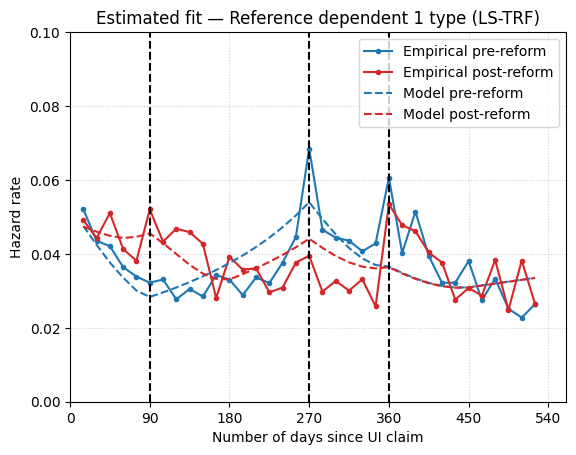

In [29]:
plot_fit(
    results[("LS-TRF", 'Reference dependent 1 type')]["params_hat"],
    'Estimated fit — Reference dependent 1 type (LS-TRF)',
    'lstrf_rd1_after.pdf',
)

## 6.5 Estimation Table 2 (LS-TRF)

In [30]:
lstrf_table = pd.DataFrame([
    result_row(results[("LS-TRF", name)])
    for name in specs.keys()
])

display(lstrf_table)

lstrf_latex = lstrf_table.to_latex(
    index=False,
    float_format=lambda x: f"{x:.4f}",
    na_rep="--",
    caption="SMM estimates using LS-TRF.",
    label="tab:lstrf_estimates",
)

print(lstrf_latex)

with open(os.path.join(TABLE_DIR, "lstrf_results.tex"), "w", encoding="utf-8") as f:
    f.write(lstrf_latex)

,Algorithm,Model,delta,gamma,eta,lambda,k1,k2,k3,q1,q2,q3,SSE,Minutes
0,scipy_ls_trf,Standard 1 type,0.91676,0.92672,0.00000,0.00000,315.82581,NaN,NaN,NaN,NaN,NaN,578.55749,1.27192
1,scipy_ls_trf,Standard 2 type,0.82785,1.36318,0.00000,0.00000,899.93787,35.91790,NaN,0.75110,NaN,0.24890,96.62646,7.82129
2,scipy_ls_trf,Standard 3 type,0.77680,1.28588,0.00000,0.00000,730.85371,200.33919,16.69599,0.48989,0.31966,0.19045,94.68896,5.88184
3,scipy_ls_trf,Reference dependent 1 type,0.94999,0.92545,1.38425,14.99342,894.31292,NaN,NaN,NaN,NaN,NaN,126.52089,2.01807


\begin{table}
\caption{SMM estimates using LS-TRF.}
\label{tab:lstrf_estimates}
\begin{tabular}{llrrrrrrrrrrrr}
\toprule
Algorithm & Model & delta & gamma & eta & lambda & k1 & k2 & k3 & q1 & q2 & q3 & SSE & Minutes \\
\midrule
scipy_ls_trf & Standard 1 type & 0.9168 & 0.9267 & 0.0000 & 0.0000 & 315.8258 & -- & -- & -- & -- & -- & 578.5575 & 1.2719 \\
scipy_ls_trf & Standard 2 type & 0.8278 & 1.3632 & 0.0000 & 0.0000 & 899.9379 & 35.9179 & -- & 0.7511 & -- & 0.2489 & 96.6265 & 7.8213 \\
scipy_ls_trf & Standard 3 type & 0.7768 & 1.2859 & 0.0000 & 0.0000 & 730.8537 & 200.3392 & 16.6960 & 0.4899 & 0.3197 & 0.1904 & 94.6890 & 5.8818 \\
scipy_ls_trf & Reference dependent 1 type & 0.9500 & 0.9255 & 1.3842 & 14.9934 & 894.3129 & -- & -- & -- & -- & -- & 126.5209 & 2.0181 \\
\bottomrule
\end{tabular}
\end{table}



# 7. Estimator comparison

This table puts the two optimizers side by side for a comparison of parameter stability, goodness of fit, and runtime.

In [31]:
combined_table = pd.concat(
    [lbfgsb_table, lstrf_table],
    ignore_index=True
).sort_values(["Model", "Algorithm"])

display(combined_table)

combined_latex = combined_table.to_latex(
    index=False,
    float_format=lambda x: f"{x:.4f}",
    na_rep="--",
    caption="SMM estimates across model specifications and optimization algorithms.",
    label="tab:all_estimates",
)

print(combined_latex)

with open(os.path.join(TABLE_DIR, "all_estimates2.tex"), "w", encoding="utf-8") as f:
    f.write(combined_latex)

,Algorithm,Model,delta,gamma,eta,lambda,k1,k2,k3,q1,q2,q3,SSE,Minutes
3,scipy_lbfgsb,Reference dependent 1 type,0.95000,0.66311,1.07307,13.87022,358.51467,NaN,NaN,NaN,NaN,NaN,133.36761,19.52800
7,scipy_ls_trf,Reference dependent 1 type,0.94999,0.92545,1.38425,14.99342,894.31292,NaN,NaN,NaN,NaN,NaN,126.52089,2.01807
0,scipy_lbfgsb,Standard 1 type,0.91381,0.97702,0.00000,0.00000,358.19481,NaN,NaN,NaN,NaN,NaN,559.74142,8.59367
4,scipy_ls_trf,Standard 1 type,0.91676,0.92672,0.00000,0.00000,315.82581,NaN,NaN,NaN,NaN,NaN,578.55749,1.27192
1,scipy_lbfgsb,Standard 2 type,0.94221,0.72519,0.00000,0.00000,300.03636,150.52343,NaN,0.60479,NaN,0.39521,517.72982,32.07506
5,scipy_ls_trf,Standard 2 type,0.82785,1.36318,0.00000,0.00000,899.93787,35.91790,NaN,0.75110,NaN,0.24890,96.62646,7.82129
2,scipy_lbfgsb,Standard 3 type,0.90327,0.79512,0.00000,0.00000,397.62695,138.62773,18.25851,0.35156,0.42486,0.22359,95.52158,68.31669
6,scipy_ls_trf,Standard 3 type,0.77680,1.28588,0.00000,0.00000,730.85371,200.33919,16.69599,0.48989,0.31966,0.19045,94.68896,5.88184


\begin{table}
\caption{SMM estimates across model specifications and optimization algorithms.}
\label{tab:all_estimates}
\begin{tabular}{llrrrrrrrrrrrr}
\toprule
Algorithm & Model & delta & gamma & eta & lambda & k1 & k2 & k3 & q1 & q2 & q3 & SSE & Minutes \\
\midrule
scipy_lbfgsb & Reference dependent 1 type & 0.9500 & 0.6631 & 1.0731 & 13.8702 & 358.5147 & -- & -- & -- & -- & -- & 133.3676 & 19.5280 \\
scipy_ls_trf & Reference dependent 1 type & 0.9500 & 0.9255 & 1.3842 & 14.9934 & 894.3129 & -- & -- & -- & -- & -- & 126.5209 & 2.0181 \\
scipy_lbfgsb & Standard 1 type & 0.9138 & 0.9770 & 0.0000 & 0.0000 & 358.1948 & -- & -- & -- & -- & -- & 559.7414 & 8.5937 \\
scipy_ls_trf & Standard 1 type & 0.9168 & 0.9267 & 0.0000 & 0.0000 & 315.8258 & -- & -- & -- & -- & -- & 578.5575 & 1.2719 \\
scipy_lbfgsb & Standard 2 type & 0.9422 & 0.7252 & 0.0000 & 0.0000 & 300.0364 & 150.5234 & -- & 0.6048 & -- & 0.3952 & 517.7298 & 32.0751 \\
scipy_ls_trf & Standard 2 type & 0.8278 & 1.3632 & 0.0000 & 0

# 8. Heterogeneity mechanism: survival and dilution of low-​`k` types

A heterogeneous-type model can generate a declining aggregate hazard even when each type's own hazard is not declining as much. Low-`k` types search more intensely, exit unemployment earlier, and therefore make up a progressively smaller share of the unemployment pool.

The cells below use the estimated **L-BFGS-B 3-type standard model**. Change `mechanism_key` to the 2-type model or LS-TRF if desired.

In [32]:
def unpack_type_structure(params_vec):
    p = np.asarray(params_vec).ravel()

    if len(p) == 6:
        delta_, gamma_, eta_, k1_, lmbda_, N_ = p
        return [k1_], np.array([1.0]), [delta_, gamma_, eta_, lmbda_, N_]

    if len(p) == 8:
        delta_, gamma_, eta_, k1_, lmbda_, N_, k2_, q1_ = p
        return [k1_, k2_], np.array([q1_, 1-q1_]), [delta_, gamma_, eta_, lmbda_, N_]

    if len(p) == 10:
        delta_, gamma_, eta_, k1_, lmbda_, N_, k2_, k3_, q1_, q2_ = p
        return [k1_, k2_, k3_], np.array([q1_, q2_, 1-q1_-q2_]), [delta_, gamma_, eta_, lmbda_, N_]

    raise ValueError("Unsupported parameter vector length.")


def type_survival_diagnostics(params_vec, institutions):
    kvals, shares, common = unpack_type_structure(params_vec)
    delta_, gamma_, eta_, lmbda_, N_ = common

    pop_survivals = []

    for k_j in kvals:
        params_j = np.array([delta_, gamma_, eta_, k_j, lmbda_, N_])
        _, _, survival_j, _, _, _ = model.SolveForward(
            params_j, institutions, abar, htm
        )

        # Integrate over the initial asset distribution within each type.
        pop_survivals.append(weights @ survival_j)

    pop_survivals = np.asarray(pop_survivals)

    survivor_mass = shares[:, None] * pop_survivals
    survivor_composition = survivor_mass / survivor_mass.sum(axis=0, keepdims=True)

    return np.asarray(kvals), shares, pop_survivals, survivor_composition


mechanism_key = ("L-BFGS-B", "Standard 3 type")
params_mech = results[mechanism_key]["params_hat"]

kvals_mech, shares_mech, survival_mech, composition_mech =     type_survival_diagnostics(params_mech, institutions_pre)

timevec_survival = np.arange(T + 1) * 15

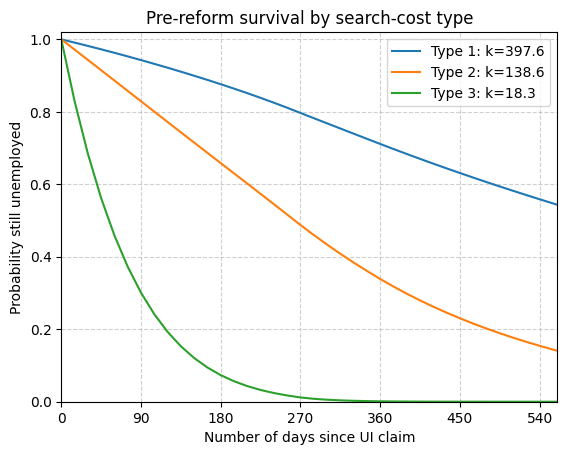

In [33]:
# Type-specific survival probabilities


for j, k_j in enumerate(kvals_mech):
    plt.plot(
        timevec_survival,
        survival_mech[j],
        label=f"Type {j+1}: k={k_j:.1f}"
    )

plt.xlabel("Number of days since UI claim")
plt.ylabel("Probability still unemployed")
plt.title("Pre-reform survival by search-cost type")
plt.xlim(0, 560)
plt.xticks(np.arange(0, 561, 90))
plt.ylim(0, 1.02)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.savefig(os.path.join(FIGURE_DIR, "type_survival_pre.pdf"), bbox_inches="tight")
plt.show()

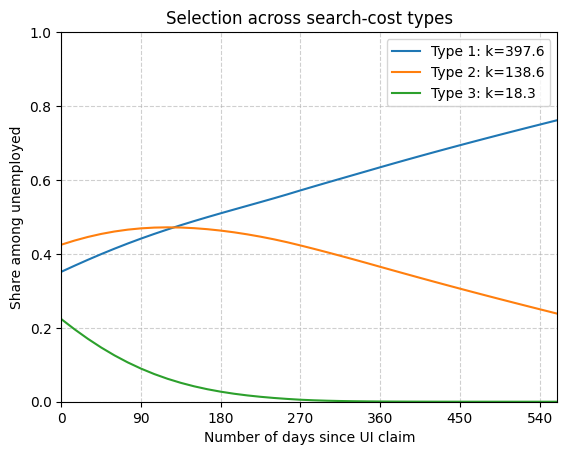

In [34]:
# Composition of the remaining unemployment pool

for j, k_j in enumerate(kvals_mech):
    plt.plot(
        timevec_survival,
        composition_mech[j],
        label=f"Type {j+1}: k={k_j:.1f}"
    )

plt.xlabel("Number of days since UI claim")
plt.ylabel("Share among unemployed")
plt.title("Selection across search-cost types")
plt.xlim(0, 560)
plt.xticks(np.arange(0, 561, 90))
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.savefig(os.path.join(FIGURE_DIR, "type_composition_pre.pdf"), bbox_inches="tight")
plt.show()

In [37]:
results[("L-BFGS-B", 'Standard 2 type')]

{'model': 'Standard 2 type',
 'algorithm': 'scipy_lbfgsb',
 'result': Minimize with 5 free parameters terminated unsuccessfully after 144 criterion evaluations, 144 derivative evaluations and 23 iterations.
 
 The value of criterion improved from 654.4424363973703 to 517.729820069245.
 
 The scipy_lbfgsb algorithm reported: ABNORMAL: 
 
 Independent of the convergence criteria used by scipy_lbfgsb, the strength of convergence can be assessed by the following criteria:
 
                           one_step   five_steps 
 relative_criterion_change   0***    3.513e-15***
 relative_params_change      0***    1.714e-14***
 absolute_criterion_change   0***    1.819e-12***
 absolute_params_change      0***    1.444e-14***
 
 (***: change <= 1e-10, **: change <= 1e-8, *: change <= 1e-5. Change refers to a change between accepted steps. The first column only considers the last step. The second column considers the last five steps.),
 'params_hat': array([  0.94221307,   0.72518965,   0.        

In [38]:
fig = om.criterion_plot(results[("L-BFGS-B", 'Standard 2 type')])
fig

FileNotFoundError: No file found at path='Standard 2 type'